# Open Notebook & Additional Resources

<a target="_blank" href="https://colab.research.google.com/github/Nicolepcx/ORM_AI_Agents_Bootcamp/blob/main/demo/DAY_1_DEMO_SESSION_2_CoT.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>
<a target="_blank" href="https://learning.oreilly.com/library/view/ai-agents-the/0642572247775/">
  <img src="https://img.shields.io/badge/AI%20Agents%20Book-Read%20on%20O'Reilly-d40101?style=flat" alt="AI Agents Book – Read on O'Reilly"/>
</a>



# About this notebook

This notebook is a hands on template for data analysis agents that mix **LangChain Functions Agents** with a tiny **LangGraph** wrapper. It shows how to drive a Python REPL tool from a CoT style prompt to load a CSV, compute stats, and save a simple chart, while returning both the final answer and intermediate tool steps.

## What it shows

* **API setup** through `.env` with `OPENAI_API_KEY` and a gentle fallback prompt.
* **A Python REPL tool** that executes code, prints results, and reports errors cleanly.
* **CoT style system instructions** that tell the agent when to call the REPL and what to produce.
* **LangChain Functions Agent** created with `create_openai_functions_agent` and wrapped in an `AgentExecutor`.
* **A minimal LangGraph** with one node that runs the agent and exposes

  * `messages` history
  * `output` (final answer)
  * `intermediate_steps` (tool calls and observations).
* **A demo CSV** created on the fly to make the run reproducible.
* **Mermaid graph render** of the one node graph.

## What you will run

1. Load `OPENAI_API_KEY` from `.env` or enter it interactively.
3. Define a **Python REPL tool** for analysis and plotting. It advises saving charts to files.
4. Build a **Functions Agent** with a prompt that

   * describes the dataset
   * highlights patterns
   * concludes with a short summary
   * calls the REPL for metrics and one bar chart if a target column is present.
5. Wrap the agent in a **one node LangGraph** and invoke it with a system message and a user message that provide the dataset path and target column.
6. Inspect the **final agent output** and the **intermediate tool steps** for transparency.
7. Optionally view a **PNG render** of the graph.

## How it works

* The **REPL tool** executes Python code inside the notebook process and returns either `OK\n<stdout>` or `ERROR <repr(e)>`.
* The **Functions Agent** decides when to call the tool and with what code, based on the system instructions and the chat history.
* The **graph node** calls the executor, captures `output` and `intermediate_steps`, and appends the final AI message back into state so you can chain future steps if needed.

## Why this pattern

* Functions Agents are strong for structured tool use. They generate callable function arguments instead of free form text.
* LangGraph gives you a light state wrapper that makes it easy to stitch this into larger workflows.
* The REPL makes the analysis verifiable, since all stats and charts are produced by code that you can read.

## Extend and adapt

* Add tools for file upload, SQL, or web fetching.
* Enforce stricter templates in the system prompt for consistent reports.
* Replace the in notebook REPL with a containerized sandbox in production.
* Add nodes for validation or report formatting before returning the final answer.

## Requirements and notes

* You need a valid `OPENAI_API_KEY`.
* The REPL runs arbitrary Python. Use a sandbox in real deployments.
* Matplotlib saves figures to files when the tool code includes the save call. The tool already reminds the model to do so.


# Dependencies

In [ ]:
!pip install -q langchain \
                langgraph==1.1.2 \
                langchain-openai==1.1.11 \
                langchain_experimental \
                python-dotenv==1.0.1 \
                langchain-core


# API Setup

In [ ]:
# --- API Key Setup ---
# Option 1 (preferred): create a `.env` file in your project folder with:
# OPENAI_API_KEY=your_openai_key_here
#
# Option 2: set it directly in the notebook with magic:
# %env OPENAI_API_KEY=your_openai_key_here


from dotenv import load_dotenv
import os

load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if not OPENAI_API_KEY:
    print("⚠️ OPENAI_API_KEY not found. You can set it with `%env` in the notebook or enter it below.")
    OPENAI_API_KEY = input("Enter your OPENAI_API_KEY: ").strip()

print("✅ API key loaded successfully!")


✅ API key loaded successfully!


# Imports

In [ ]:
from typing import TypedDict, List, Any, Dict
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from langchain_openai import ChatOpenAI
from langchain.tools import tool
from langchain_experimental.utilities import PythonREPL
from langchain.agents import create_agent
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, BaseMessage

from langgraph.graph import StateGraph, START, END



# Tool: Python REPL

In [ ]:
repl = PythonREPL()  # Use a sandbox in production

@tool
def python_repl(code: str) -> str:
    """Execute Python code for data analysis. Always print results. Save charts to files if created."""
    try:
        out = repl.run(code)
        return f"OK\n{out}"
    except BaseException as e:
        return f"ERROR {repr(e)}"

tools = [python_repl]




# CoT style system prompt

In [ ]:
SYSTEM_INSTRUCTIONS = """You are a careful data analysis assistant. Think step by step and be explicit.
Begin by describing the dataset.
Next highlight patterns or trends.
Conclude with a clear summary of insights.
When you need to compute metrics or create a chart, call the python_repl tool with code that:
1. Loads the CSV from the dataset path
2. Prints descriptive statistics
3. If a target column exists, creates one bar chart of mean values grouped by the target and saves it to a file
4. Prints key results
Return FINAL ANSWER only after you have executed your analysis."""



# LangGraph state and node

In [ ]:
class AgentState(TypedDict):
    messages: List[BaseMessage]
    output: str
    intermediate_steps: Any


llm = ChatOpenAI(model="gpt-5.4-mini", temperature=0)

# New LangChain style agent
agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt=SYSTEM_INSTRUCTIONS,
)


def agent_node(state: AgentState) -> Dict[str, Any]:
    result = agent.invoke({"messages": state["messages"]})

    # result is a dict with updated messages
    messages = result.get("messages", [])
    output = ""

    # Grab the final AI message content
    if messages:
        last_msg = messages[-1]
        if hasattr(last_msg, "content"):
            output = last_msg.content

    return {
        "messages": messages,
        "output": output,
        "intermediate_steps": result,  # optional, useful for inspection
    }



# Build a tiny one-node graph

In [ ]:
builder = StateGraph(AgentState)
builder.add_node("agent", agent_node)
builder.add_edge(START, "agent")
builder.add_edge("agent", END)
app = builder.compile()


# Demo dataset and run


=== Agent output ===

Here’s a concise analysis of `demo.csv`.

### Dataset description
- **Shape:** 5 rows × 3 columns
- **Columns:**
  - `city` (categorical)
  - `sales` (numeric)
  - `cost` (numeric)
- **Missing values:** None

### Descriptive statistics
- **Sales**
  - Mean: **10.8**
  - Min/Max: **8 to 15**
  - Standard deviation: **2.77**
- **Cost**
  - Mean: **3.2**
  - Min/Max: **2 to 5**
  - Standard deviation: **1.30**

### Patterns and trends
Grouped by `city`, the average values are:
- **City A:** sales **11.0**, cost **3.5**
- **City B:** sales **8.5**, cost **2.0**
- **City C:** sales **15.0**, cost **5.0**

Key pattern:
- **City C** has the highest average sales and highest average cost.
- **City B** has the lowest sales and lowest cost.
- **City A** is in the middle on both measures.

### Summary of insights
This is a very small, clean dataset with no missing values. The main trend is a clear ordering across cities: **City C > City A > City B** for both sales and cost.

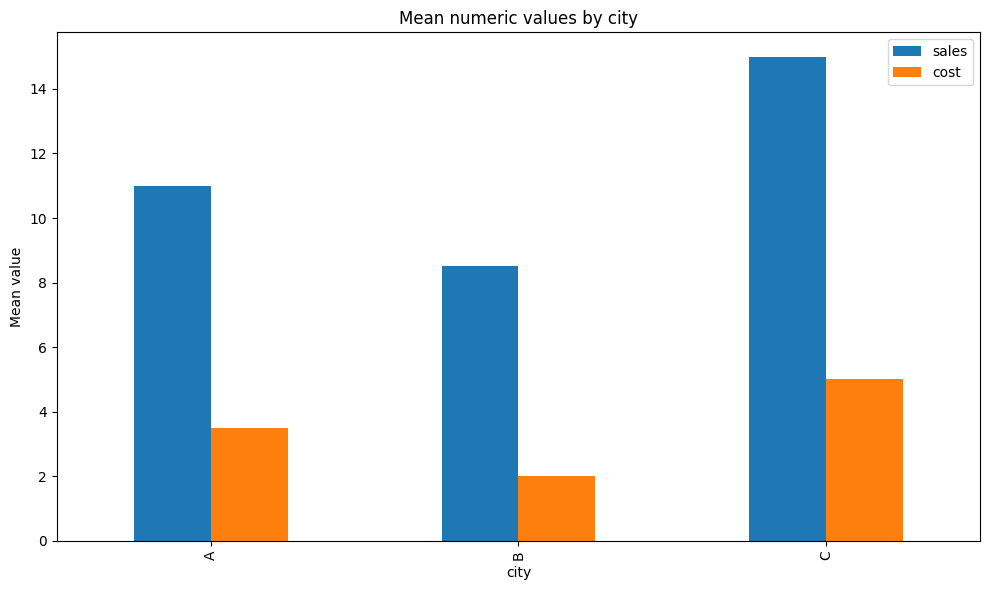

In [ ]:
demo_csv = Path("demo.csv")
if not demo_csv.exists():
    df = pd.DataFrame({
        "city": ["A", "A", "B", "B", "C"],
        "sales": [10, 12, 8, 9, 15],
        "cost": [3, 4, 2, 2, 5]
    })
    df.to_csv(demo_csv, index=False)

dataset_path = str(demo_csv)
target = "city"

system = SystemMessage(content=SYSTEM_INSTRUCTIONS)
human = HumanMessage(content=f"Dataset path: {dataset_path}\nTarget column: {target}")

initial_state: AgentState = {
    "messages": [system, human],
    "output": "",
    "intermediate_steps": [],
}

final = app.invoke(initial_state)

print("\n=== Agent output ===\n")
print(final.get("output", ""))

print("\n=== Raw result / intermediate info ===\n")
print(final.get("intermediate_steps", ""))


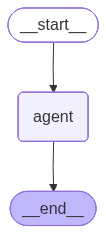

In [ ]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))